# Notebook 08 — ML Models (LightGBM)
Train three LightGBM models (L1, L2, Huber) with early stopping, compare metrics, and save.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('..'))

import pandas as pd
import numpy as np
import pickle
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import warnings
warnings.filterwarnings('ignore')

from pathlib import Path

from src.utils import load_config, set_seed, ensure_dirs
from src.data_loader import load_all
from src.features.pipeline import build_feature_matrix
from src.models.gbm import (
    train_lgbm_l1, train_lgbm_l2, train_lgbm_huber,
    get_feature_cols, save_model
)
from src.metrics import evaluate, compare_models

cfg = load_config('../config.yaml')
cfg['paths']['dataset']     = '../dataset'
cfg['paths']['outputs']     = '../outputs'
cfg['paths']['figures']     = '../outputs/figures'
cfg['paths']['models']      = '../outputs/models'
cfg['paths']['cv_results']  = '../outputs/cv_results'
cfg['paths']['submissions'] = '../outputs/submissions'
cfg['paths']['report_figures'] = '../report/figures'

set_seed(cfg['seed'])
ensure_dirs(cfg)
print('Config loaded.')

Config loaded.


In [2]:
# Load or build feature matrix
FEAT_PATH = '../outputs/feature_matrix.parquet'

if Path(FEAT_PATH).exists():
    print(f'Loading existing feature matrix from {FEAT_PATH}...')
    df = pd.read_parquet(FEAT_PATH)
else:
    print('Feature matrix not found — building...')
    tables = load_all(cfg)
    df = build_feature_matrix(cfg, tables, save_path=FEAT_PATH)

print(f'Feature matrix shape: {df.shape}')
print(f'Date range: {df["Date"].min().date()} to {df["Date"].max().date()}')

Loading existing feature matrix from ../outputs/feature_matrix.parquet...
Feature matrix shape: (4381, 220)
Date range: 2012-07-04 to 2024-07-01


In [3]:
# Feature selection and train/val split
TRAIN_END = '2021-12-31'
VAL_START = '2022-01-01'
VAL_END   = '2022-12-31'

train = df[df['Date'] <= TRAIN_END].copy()
val   = df[(df['Date'] >= VAL_START) & (df['Date'] <= VAL_END)].copy()

print(f'Train: {len(train)} rows')
print(f'Val  : {len(val)} rows')

feat_cols = get_feature_cols(df)
print(f'Feature columns: {len(feat_cols)}')

X_tr = train[feat_cols].fillna(0)
y_tr = train['Revenue']
X_vl = val[feat_cols].fillna(0)
y_vl = val['Revenue']

Train: 3468 rows
Val  : 365 rows
Feature columns: 217


In [4]:
# Train 3 LightGBM models
print('=== Training LGBM L1 (MAE loss) ===')
m_l1 = train_lgbm_l1(X_tr, y_tr, X_vl, y_vl, seed=cfg['seed'])
preds_l1 = m_l1.predict(X_vl)
metrics_l1 = evaluate(y_vl.values, preds_l1, label='LGBM-L1')

print('\n=== Training LGBM L2 (RMSE loss) ===')
m_l2 = train_lgbm_l2(X_tr, y_tr, X_vl, y_vl, seed=cfg['seed'])
preds_l2 = m_l2.predict(X_vl)
metrics_l2 = evaluate(y_vl.values, preds_l2, label='LGBM-L2')

print('\n=== Training LGBM Huber (alpha=1.0) ===')
m_hub = train_lgbm_huber(X_tr, y_tr, X_vl, y_vl, alpha=1.0, seed=cfg['seed'])
preds_hub = m_hub.predict(X_vl)
metrics_hub = evaluate(y_vl.values, preds_hub, label='LGBM-Huber')

=== Training LGBM L1 (MAE loss) ===
[LGBM-regression_l1]  MAE=573,657  RMSE=798,593  R2=0.7724  Composite=0.3735
[LGBM-L1]  MAE=573,657  RMSE=798,593  R2=0.7724  Composite=0.3735

=== Training LGBM L2 (RMSE loss) ===
[LGBM-regression]  MAE=566,102  RMSE=757,959  R2=0.7949  Composite=0.3574
[LGBM-L2]  MAE=566,102  RMSE=757,959  R2=0.7949  Composite=0.3574

=== Training LGBM Huber (alpha=1.0) ===
[LGBM-huber]  MAE=1,746,007  RMSE=2,056,928  R2=-0.5102  Composite=1.2108
[LGBM-Huber]  MAE=1,746,007  RMSE=2,056,928  R2=-0.5102  Composite=1.2108


In [5]:
# Comparison table
results = {
    'LGBM-L1': metrics_l1,
    'LGBM-L2': metrics_l2,
    'LGBM-Huber': metrics_hub,
}
print('\n=== ML Model Comparison (Val 2022) ===')
display(compare_models(results))


=== ML Model Comparison (Val 2022) ===


,mae,rmse,r2,composite
LGBM-L2,"566,102","757,959",0.7949,0.3574
LGBM-L1,"573,657","798,593",0.7724,0.3735
LGBM-Huber,"1,746,007","2,056,928",-0.5102,1.2108


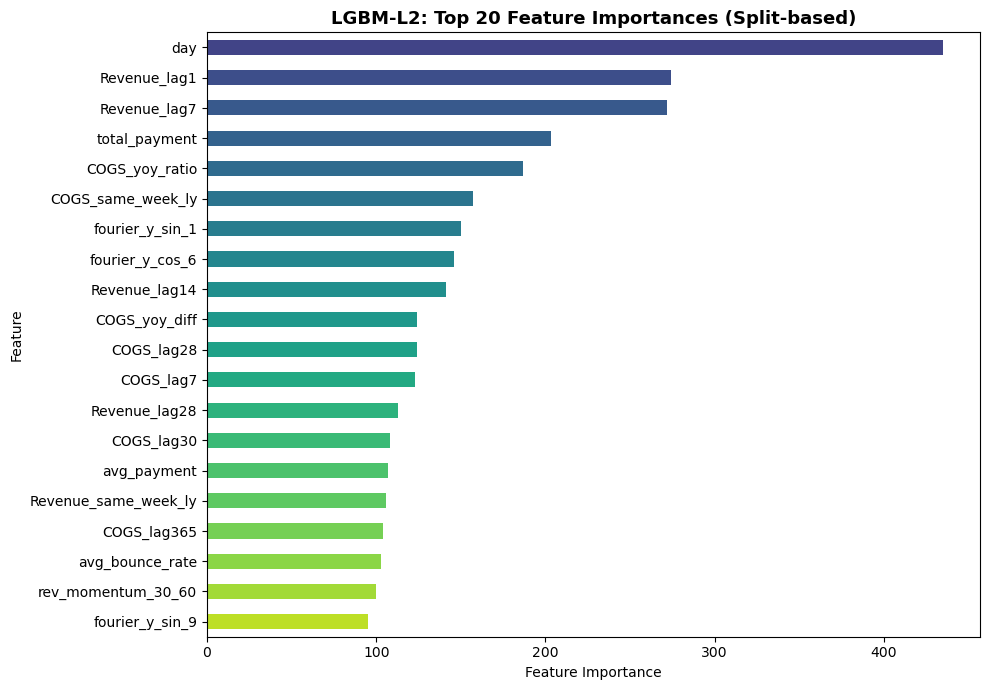

Saved: ../outputs/figures/08_lgbm_l2_feature_importance.png


In [6]:
# Feature importance: LGBM-L2 top 20
import lightgbm as lgb

fi = pd.DataFrame({
    'feature': feat_cols,
    'importance': m_l2.feature_importances_
}).sort_values('importance', ascending=False)

fig, ax = plt.subplots(figsize=(10, 7))
top20_fi = fi.head(20)
colors_fi = plt.cm.viridis(np.linspace(0.2, 0.9, 20))
top20_fi[::-1].plot(
    kind='barh', x='feature', y='importance',
    ax=ax, color=colors_fi[::-1], legend=False
)
ax.set_title('LGBM-L2: Top 20 Feature Importances (Split-based)', fontsize=13, fontweight='bold')
ax.set_xlabel('Feature Importance')
ax.set_ylabel('Feature')
plt.tight_layout()

fi_path = cfg['paths']['figures'] + '/08_lgbm_l2_feature_importance.png'
fig.savefig(fi_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: {fi_path}')

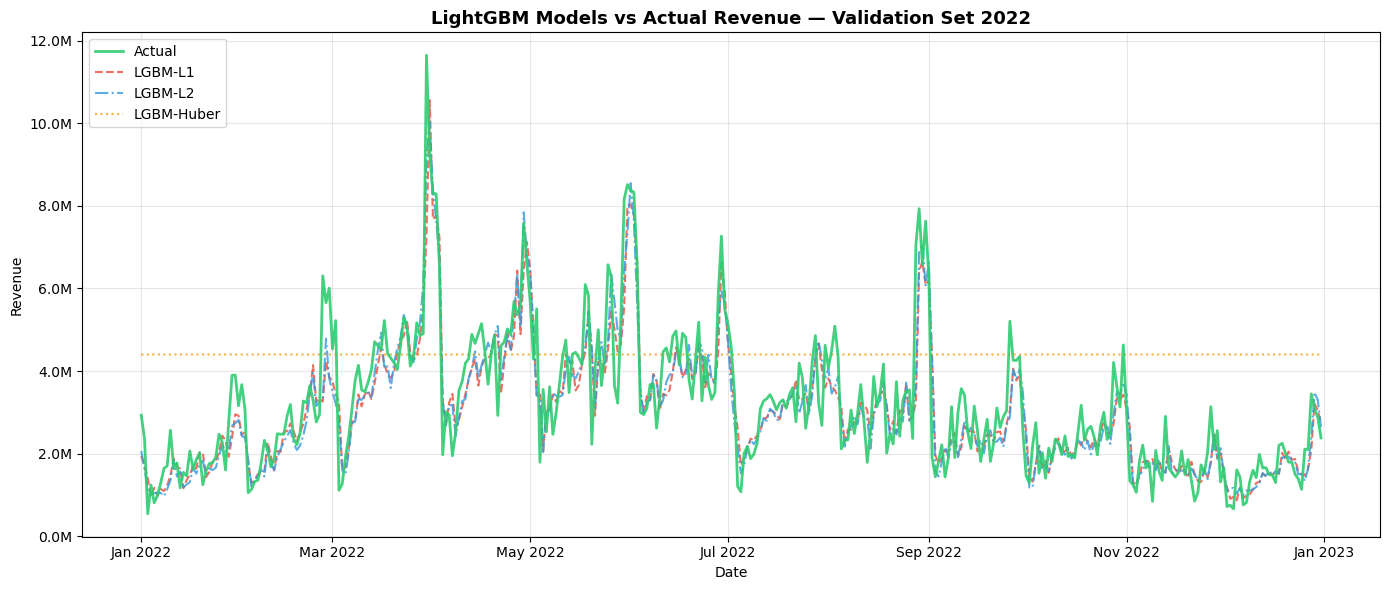

Saved: ../outputs/figures/08_lgbm_predictions_val.png


In [7]:
# Plot: Actual vs 3 model predictions on val set
val_dates = val['Date'].values
actual    = y_vl.values

fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(val_dates, actual,    color='#2ecc71', lw=2,   label='Actual', alpha=0.9, zorder=5)
ax.plot(val_dates, preds_l1,  color='#e74c3c', lw=1.5, ls='--', label='LGBM-L1', alpha=0.8)
ax.plot(val_dates, preds_l2,  color='#3498db', lw=1.5, ls='-.',  label='LGBM-L2', alpha=0.8)
ax.plot(val_dates, preds_hub, color='#f39c12', lw=1.5, ls=':',   label='LGBM-Huber', alpha=0.8)

ax.set_title('LightGBM Models vs Actual Revenue — Validation Set 2022', fontsize=13, fontweight='bold')
ax.set_xlabel('Date')
ax.set_ylabel('Revenue')
ax.legend(loc='upper left')
ax.grid(True, alpha=0.3)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x/1e6:.1f}M'))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
plt.tight_layout()

pred_path = cfg['paths']['figures'] + '/08_lgbm_predictions_val.png'
fig.savefig(pred_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: {pred_path}')

In [8]:
# Save models and predictions
save_model(m_l1,  'lgbm_l1',    cfg['paths']['models'])
save_model(m_l2,  'lgbm_l2',    cfg['paths']['models'])
save_model(m_hub, 'lgbm_huber', cfg['paths']['models'])

ml_preds = pd.DataFrame({
    'Date':       val['Date'].values,
    'Actual':     actual,
    'LGBM_L1':    preds_l1,
    'LGBM_L2':    preds_l2,
    'LGBM_Huber': preds_hub,
})
ml_path = cfg['paths']['cv_results'] + '/ml_preds.csv'
ml_preds.to_csv(ml_path, index=False)
print(f'ML predictions saved: {ml_path}')

# Save feature importance table
fi_csv_path = cfg['paths']['cv_results'] + '/feature_importance_lgbm_l2.csv'
fi.to_csv(fi_csv_path, index=False)
print(f'Feature importance saved: {fi_csv_path}')
print('\nML modeling notebook complete.')

[10:24:42] INFO gbm: Saved lgbm_l1 to ../outputs/models/lgbm_l1.pkl
[10:24:42] INFO gbm: Saved lgbm_l2 to ../outputs/models/lgbm_l2.pkl
[10:24:42] INFO gbm: Saved lgbm_huber to ../outputs/models/lgbm_huber.pkl


ML predictions saved: ../outputs/cv_results/ml_preds.csv
Feature importance saved: ../outputs/cv_results/feature_importance_lgbm_l2.csv

ML modeling notebook complete.
